# Project 02

## Import helpers

Run the following $2$ cells to download and import helper functions, files and libraries.

You might not need them, but they're here just in case.

In [1]:
!wget -q https://github.com/PSAM-5005-2026S-A/5005-utils/raw/main/src/audio_utils.py
!wget -q https://github.com/PSAM-5005-2026S-A/5005-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5005-2026S-A/5005-utils/raw/main/src/image_utils.py

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from data_utils import image_from_url, list_from_csv_url, object_from_json_url

## Milestone 02

Start bringing data into your project here

In [ ]:
import pandas as pd    ## imported my data!

df0 = pd.read_json("data/StreamingHistory_music_0.json")
df1 = pd.read_json("data/StreamingHistory_music_1.json")

In [ ]:
df = pd.concat([df0, df1], ignore_index=True)    ## get information(title) of my data
df.columns

Index(['endTime', 'artistName', 'trackName', 'msPlayed'], dtype='object')

In [7]:
df['endTime'] = pd.to_datetime(df['endTime'])

df['hour'] = df['endTime'].dt.hour
df['day'] = df['endTime'].dt.day_name()
df['month'] = df['endTime'].dt.month
df['year'] = df['endTime'].dt.year

In [8]:
df.head()

,endTime,artistName,trackName,msPlayed,hour,day,month,year
0,2025-04-29 16:37:00,IZ*ONE,Secret Story of the Swan,158708,16,Tuesday,4,2025
1,2025-04-30 00:09:00,Ice Paper,心如止水,4094,0,Wednesday,4,2025
2,2025-04-30 00:09:00,Sam Smith,I'm Not The Only One,2233,0,Wednesday,4,2025
3,2025-04-30 00:13:00,Justin Nozuka,What’s The Point,233160,0,Wednesday,4,2025
4,2025-04-30 00:16:00,Hotel Ugly,Shut up My Moms Calling,164571,0,Wednesday,4,2025


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14867 entries, 0 to 14866
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   endTime     14867 non-null  datetime64[ns]
 1   artistName  14867 non-null  object        
 2   trackName   14867 non-null  object        
 3   msPlayed    14867 non-null  int64         
 4   hour        14867 non-null  int32         
 5   day         14867 non-null  object        
 6   month       14867 non-null  int32         
 7   year        14867 non-null  int32         
dtypes: datetime64[ns](1), int32(3), int64(1), object(3)
memory usage: 755.1+ KB


In [10]:
df = df[df['msPlayed'] > 30000] ##filter out songs that i only played within 30s

In [ ]:
## my top artists
df['artistName'].value_counts().head(10)

artistName
Jay Chou       460
David Tao      396
BAEKHYUN       351
EXO            287
aespa          231
Leehom Wang    220
NewJeans       190
Khalil Fong    189
Masiwei        172
TWICE          150
Name: count, dtype: int64

In [ ]:
## my top songs       (interesting! it really match with my year report from Spotify)
df['trackName'].value_counts().head(10)

trackName
Supernatural               43
Shut up My Moms Calling    36
Armageddon                 35
luther (with sza)          34
like JENNIE                34
紅豆                         34
Candy                      34
Snooze                     32
Red Lips                   31
Bambi                      31
Name: count, dtype: int64

#### Milestone 2 Markdown

The dataset contains over 14000 listening records collected from my Spotify streaming history.
By converting timestamps into datetime values, I was able to analyze listening habits across different hours, days, and months.
This preprocessing step transforms raw listening logs into a dataset that can reveal behavioral and emotional patterns over time.
I did some fun experience with the dataset and got information like what are my top artists or songs. I also remove songs that i didnt play for more than 30s to make the data more accurate.

## Milestone 03

Continue pulling and organizing data here

This visualization reveals my listening behavior throughout the day. I noticed a significant increase in listening activity late at night, especially after midnight, which may reflect study habits, insomnia, or emotional routines connected to music consumption.

<Axes: xlabel='hour'>

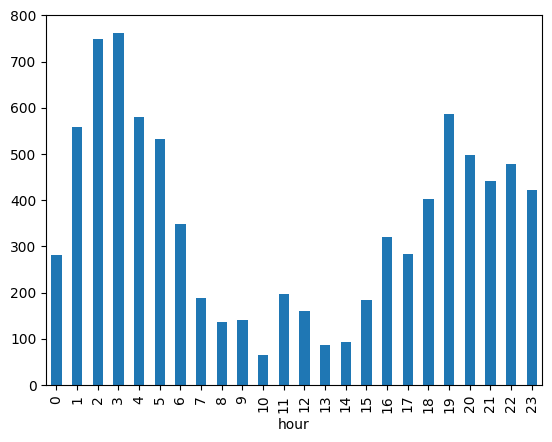

In [14]:
hourly = df.groupby('hour').size()

hourly.plot(kind='bar')

Certain artists appear repeatedly across long periods of time, suggesting emotional attachment and habitual listening patterns rather than temporary trends.

<Axes: xlabel='artistName'>

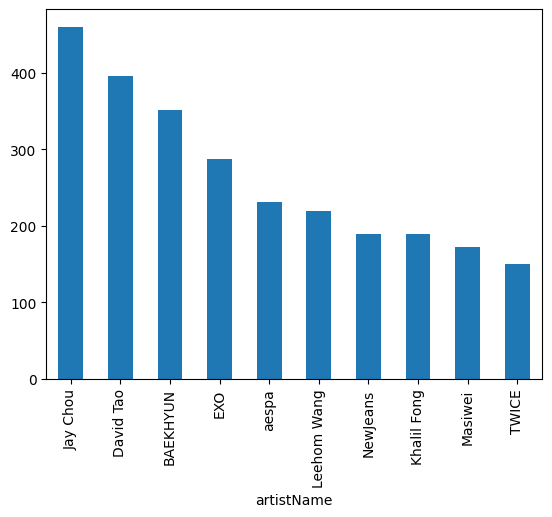

In [15]:
top_artists = df['artistName'].value_counts().head(10)

top_artists.plot(kind='bar')

diagram below is about songs i listen to for the most times. I asked Python to ignore warnings because it doesnt recognize Chinese or Japanese characters in titles

<Axes: xlabel='trackName'>

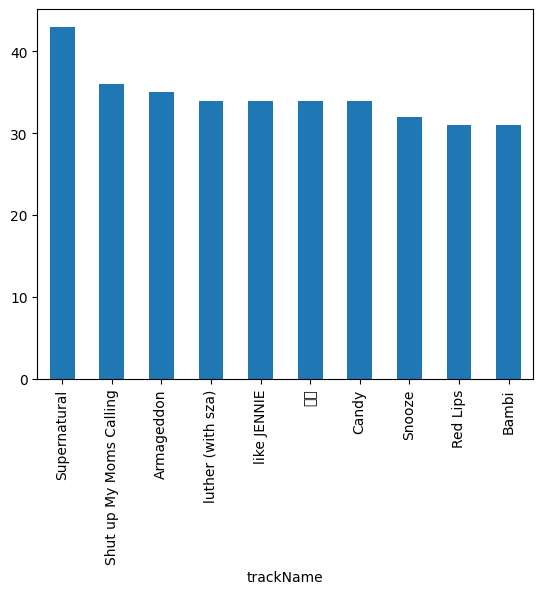

In [27]:
import warnings
warnings.filterwarnings('ignore')

top_tracks = df['trackName'].value_counts().head(10)
top_tracks.plot(kind='bar')

Listening by Month

<Axes: xlabel='month'>

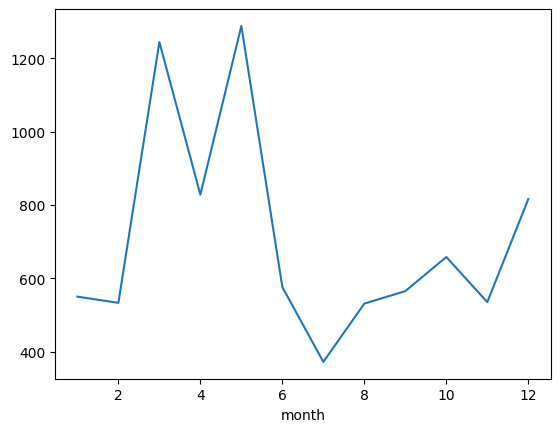

In [17]:
monthly = df.groupby('month').size()

monthly.plot(kind='line')

Late Night Analysis

<Axes: xlabel='trackName'>

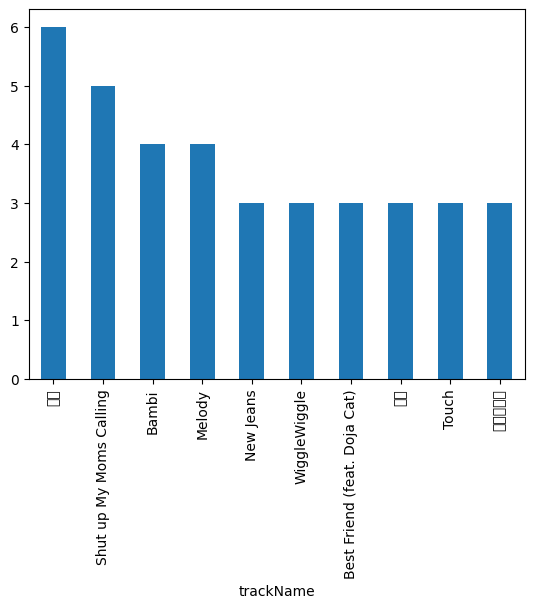

In [25]:
import warnings
warnings.filterwarnings('ignore')
late_night['trackName'].value_counts().head(10).plot(kind='bar')